## Trying the Euler-Bernoulli problem with JAX

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import matplotlib.pyplot as plt
import optax
from typing import List
from jax.example_libraries import optimizers

import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, simplify, Eq, solve, Derivative, dsolve, Function
from sympy import lambdify
from sympy import trigsimp, re

In [2]:
L = 1.0
E = 200e9
b = 0.20
h = 0.60
I = (b * h**3) / 12
q = 5e3
cf = 0
F0 = 2e3
M0 = 4e3

In [3]:
N_DOF_FD = 250
N_COLLOCATION_POINTS = 250
N_OPTIMIZATION_EPOCHS = 100_000
BC_LOSS_PHYSICS = 1.0 / E
BC_LOSS_WEIGHT = 1.0
BC_LOSS_WEIGHT_1 = 1.0/I  # v(0) = 0
BC_LOSS_WEIGHT_2 = 1.0/I  # v'(0) = 0
BC_LOSS_WEIGHT_3 = 1.0/(E * I)  # EIv'''(L) = 
BC_LOSS_WEIGHT_4 = 1.0/(E * I)  # EIv'''(L) = 

In [4]:
key = jax.random.PRNGKey(42)

In [5]:
# Our PINN is a coordinate network in the form of a MLP, mapping to scalar to scalar values
key, init_key = jr.split(key)
pinn = eqx.nn.MLP(
    in_size="scalar",
    out_size="scalar",
    width_size=64,
    depth=5,
    activation=jax.nn.sigmoid,
    key=init_key,
)

In [7]:
mesh_full = jnp.linspace(0.0, L, N_DOF_FD + 2)

In [8]:
mesh_interior = mesh_full[1:-1]

In [9]:
def get_analytical_solution_no_cf(x_analytical, L_in, E_in, I_in, F0_in, M0_in, q_in):
    # Declaração simbólica
    E, I, L, Fo, Mo, q = symbols('E I L Fo Mo q')
    x = symbols('x', real=True)
    v = Function('v')

    # EDO simbolicamente
    edo = Eq(E*I*Derivative(v(x), x, 4), q)

    # Resolve simbolicamente
    sol_geral = dsolve(edo, v(x))
    v_gen = sol_geral.rhs

    v1 = v_gen.diff(x, 1)
    v2 = v_gen.diff(x, 2)
    v3 = v_gen.diff(x, 3)

    conds = [
        Eq(v_gen.subs(x, 0), 0),
        Eq(v1.subs(x, 0), 0),
        Eq(v2.subs(x, L), -Mo / (E * I)),
        Eq(v3.subs(x, L), -Fo / (E * I)),
    ]

    # Descobre as constantes C1, C2...
    constantes = list(v_gen.free_symbols - {x, E, I, L, Fo, Mo, q})
    sol_consts = solve(conds, constantes)

    # Substitui as constantes na solução geral
    v_final = simplify(v_gen.subs(sol_consts))

    # Valores numéricos
    valores = {
        E: E_in,
        L: L_in,
        I: I_in,
        q: q_in,
        Fo: F0_in,
        Mo: M0_in,
    }

    v_final_n = (v_final.subs(valores))
    v_final_nu = trigsimp(v_final_n)
    v_final_num = re(v_final_nu)

    # Transformar em função para plotar
    u_func = lambdify(x, v_final_num, modules='numpy')
    y_vals = u_func(x_analytical)

    return y_vals

In [10]:
y_exact = get_analytical_solution_no_cf(mesh_full, L, E, I, F0, M0, q)

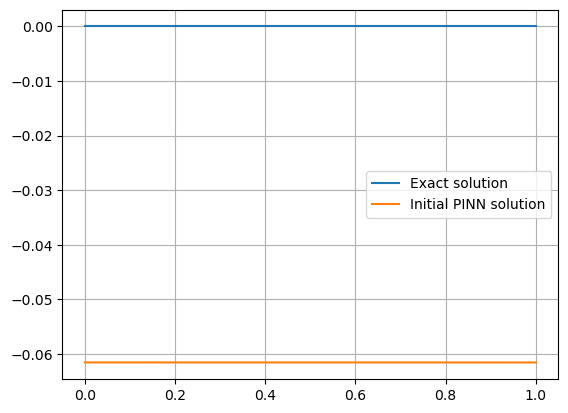

In [11]:
plt.plot(mesh_full, y_exact, label="Exact solution")
plt.plot(mesh_full, jax.vmap(pinn)(mesh_full), label="Initial PINN solution")
plt.legend()
plt.grid()

In [12]:
def pde_residuum(network, x):
    return E * I * jax.grad(jax.grad(jax.grad(jax.grad(network))))(x) \
           + cf * network(x) - q

In [14]:
key, sampling_key = jr.split(key)
collocation_points = jr.uniform(sampling_key, (N_COLLOCATION_POINTS, ), minval=0.0 + 0.001, maxval=L - 0.001)

def loss_fn(network):
    pde_residuum_at_collocation_points = jax.vmap(pde_residuum, in_axes=(None, 0))(network, collocation_points)
    pde_loss_contribution = 0.5 * jnp.mean(jnp.square(pde_residuum_at_collocation_points))

    bc_residuum_1 = network(0.0) - 0.0
    bc_residuum_2 = jax.grad(network)(0.0) - 0.0
    bc_residuum_3 = E * I * jax.grad(jax.grad(network))(L) + M0
    bc_residuum_4 = E * I * jax.grad(jax.grad(jax.grad(network)))(L) + F0
    bc_residuum_contribution = 0.5 * jnp.mean(jnp.square(bc_residuum_1)) * BC_LOSS_WEIGHT_1 \
                             + 0.5 * jnp.mean(jnp.square(bc_residuum_2)) * BC_LOSS_WEIGHT_2 \
                             + 0.5 * jnp.mean(jnp.square(bc_residuum_3)) * BC_LOSS_WEIGHT_3 \
                             + 0.5 * jnp.mean(jnp.square(bc_residuum_4)) * BC_LOSS_WEIGHT_4

    total_loss = BC_LOSS_PHYSICS * pde_loss_contribution + BC_LOSS_WEIGHT * bc_residuum_contribution

    return total_loss

In [15]:
# Training loop
lr = optimizers.exponential_decay(1e-5, decay_steps=1500, decay_rate=0.85)
optimizer = optax.adam(lr)
#optimizer = optax.adam(LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(pinn, eqx.is_array))

@eqx.filter_jit
def make_step(network, state):
    loss, grad = eqx.filter_value_and_grad(loss_fn)(network)
    updates, new_state = optimizer.update(grad, state, network)
    new_network = eqx.apply_updates(network, updates)
    return new_network, new_state, loss

loss_history = []
for epoch in range(N_OPTIMIZATION_EPOCHS):
    pinn, opt_state, loss = make_step(pinn, opt_state)
    loss_history.append(loss)
    if epoch % 100 == 0:
        print(f"Epoch: {epoch}, loss: {loss}")

Epoch: 0, loss: 0.5639410614967346
Epoch: 100, loss: 0.025301527231931686
Epoch: 200, loss: 0.00043265888234600425
Epoch: 300, loss: 6.392795057763578e-06
Epoch: 400, loss: 1.658087739997427e-06
Epoch: 500, loss: 1.6399869764427422e-06
Epoch: 600, loss: 1.6348951703548664e-06
Epoch: 700, loss: 1.629441385375685e-06
Epoch: 800, loss: 1.6235505881923018e-06
Epoch: 900, loss: 1.6172278947124141e-06
Epoch: 1000, loss: 1.610507183613663e-06
Epoch: 1100, loss: 1.6033910696933162e-06
Epoch: 1200, loss: 1.5958955827954924e-06
Epoch: 1300, loss: 1.58801481120463e-06
Epoch: 1400, loss: 1.5797245396242943e-06
Epoch: 1500, loss: 1.5710729712736793e-06
Epoch: 1600, loss: 1.5620515796399559e-06
Epoch: 1700, loss: 1.5526798051723745e-06
Epoch: 1800, loss: 1.542982545288396e-06
Epoch: 1900, loss: 1.5329711686717928e-06
Epoch: 2000, loss: 1.5226409004753805e-06
Epoch: 2100, loss: 1.51200765685644e-06
Epoch: 2200, loss: 1.5010833749329322e-06
Epoch: 2300, loss: 1.489901933382498e-06
Epoch: 2400, loss: 1

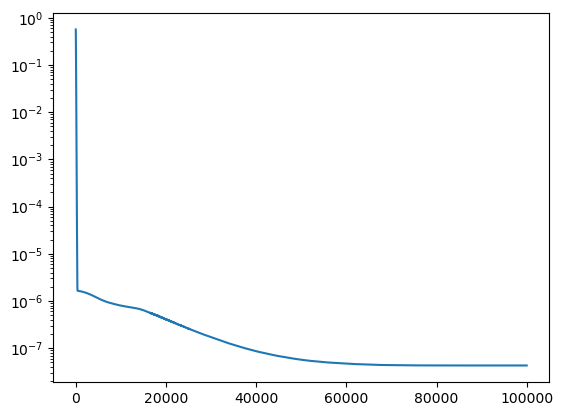

In [16]:
plt.plot(loss_history)
plt.yscale("log")

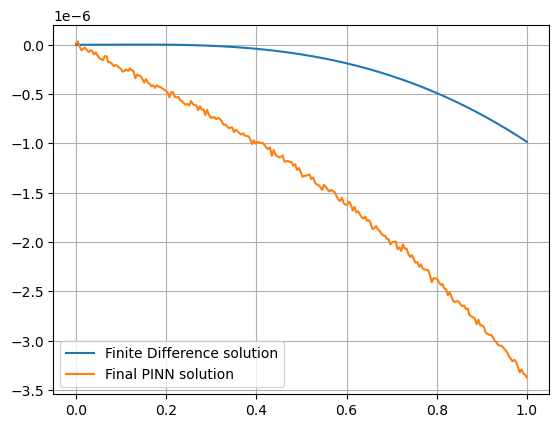

In [17]:
plt.plot(mesh_full, y_exact, label="Finite Difference solution")
plt.plot(mesh_full, jax.vmap(pinn)(mesh_full), label="Final PINN solution")
plt.legend()
plt.grid()